In [ ]:
import re
import pandas as pd
from bs4 import BeautifulSoup
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from tqdm import tqdm

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving final_dataset.xlsx to final_dataset.xlsx


In [ ]:
df1 = pd.read_csv("pubmed_ALL_cancer_environment_20251214_010208.csv")

In [ ]:
df2 = pd.read_csv("pubmed_ALL_diabetes_environment_20251214_012014.csv")

In [ ]:
df3= pd.read_csv("pubmed_ALL_heart_environment_20251214_011142.csv")

In [ ]:
df4 = pd.read_csv("pubmed_ALL_lung_environment_20251214_011723.csv")

In [ ]:
df5 = pd.read_csv("cancer.csv")

In [ ]:
df6 = pd.read_csv("chronic disease.csv")

In [ ]:
df7 = pd.read_csv("diabetes.csv")

In [ ]:
df8 = pd.read_csv("heart disese.csv")

In [ ]:
df9 = pd.read_csv("lung.csv")

In [ ]:
df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9], ignore_index=True)
print(df)

            PMID                                              Title  \
0       41077261  Comprehensive study of radon levels, health ri...   
1       41130130  Participatory science to action: Radon literac...   
2       41187632  Evaluating overestimated radon risk in predict...   
3       40985860  The diagnostic potential of urinary volatile o...   
4       40756629  Organ-level radiation dose estimations from ca...   
...          ...                                                ...   
132769  14114802  BRONCHIAL ASTHMA ASSOCIATED WITH AIR POLLUTANT...   
132770  14108696  [ON THE EFFECT OF EXPOSURE TO DUST ON THE AIRW...   
132771  14493200  [Aerobiological study of the air of Valencia a...   
132772  14493197  [Aerobiological study of the air of Valencia a...   
132773  13705443  Recent epidemiological evidence from the Unite...   

                                                 Abstract  \
0       Water quality assessment represents a fundamen...   
1       Low radon testing

In [ ]:
df.columns

Index(['PMID', 'Title', 'Abstract', 'Authors', 'Affiliation', 'Country',
       'Journal', 'Year', 'DOI', 'URL', 'Keywords', 'Study_Type', 'Funding',
       'PMC_ID', 'Timestamp', 'Assiciation'],
      dtype='object')

In [ ]:
df_cleaned = df.drop_duplicates(subset=['Abstract'])
df_cleaned

,PMID,Title,Abstract,Authors,Affiliation,Country,Journal,Year,DOI,URL,Keywords,Study_Type,Funding,PMC_ID,Timestamp,Assiciation
0,41077261,"Comprehensive study of radon levels, health ri...",Water quality assessment represents a fundamen...,Mohammad Qadr Hiwa; Farhad Salih Najeba; Amin ...,"Department of Physics, College of Science, Uni...",NaN,Regulatory toxicology and pharmacology : RTP,2026,NaN,https://pubmed.ncbi.nlm.nih.gov/41077261/,NaN,NaN,NaN,NaN,NaN,NaN
1,41130130,Participatory science to action: Radon literac...,Low radon testing rates in communities of colo...,Dai Dajun; Jelks Na'Taki Osborne; Smith Gwendy...,"Department of Geosciences, Georgia State Unive...",Usa,Journal of environmental radioactivity,2026,NaN,https://pubmed.ncbi.nlm.nih.gov/41130130/,NaN,NaN,NaN,NaN,NaN,NaN
2,41187632,Evaluating overestimated radon risk in predict...,Radon is recognised as the second most signifi...,Tejado-Ramos Juan-José; Alvarez-Toral Aitor; G...,Technological Institute of Ornamental Rocks an...,Spain,Journal of environmental radioactivity,2026,NaN,https://pubmed.ncbi.nlm.nih.gov/41187632/,NaN,NaN,NaN,NaN,NaN,NaN
3,40985860,The diagnostic potential of urinary volatile o...,Post-colonoscopy colorectal cancer (CRC) rates...,van Liere Elsa L S A; Ramsoekh Dewkoemar; Stew...,"Department of Gastroenterology and Hepatology,...",Uk,International journal of cancer,2026,NaN,https://pubmed.ncbi.nlm.nih.gov/40985860/,NaN,NaN,NaN,NaN,NaN,NaN
4,40756629,Organ-level radiation dose estimations from ca...,Children with congenital heart disease (CHD) u...,Wong-Siegel Jeannette R; Glatz Andrew C; Zampi...,New York-Presbyterian Morgan Stanley Children'...,NaN,"Radiation physics and chemistry (Oxford, Engla...",2026,NaN,https://pubmed.ncbi.nlm.nih.gov/40756629/,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132754,6968899,[Asthma and environment (author's transl)].,Asthma which includes an important bronchial h...,Charpin J,NaN,NaN,Le Poumon et le coeur,1980,NaN,https://pubmed.ncbi.nlm.nih.gov/6968899/,NaN,NaN,NaN,NaN,NaN,NaN
132760,970728,Respiratory function and symptoms in urban off...,Similar populations of male and female office ...,Linn W S; Hackney J D; Pedersen E E; Breisache...,NaN,NaN,The American review of respiratory disease,1976,NaN,https://pubmed.ncbi.nlm.nih.gov/970728/,NaN,NaN,NaN,NaN,NaN,NaN
132762,1191842,A temporary decrease in the ventilatory functi...,During a short period of increased air polluti...,Lende R; Huygen C; Jansen-Koster E J; Knijpstr...,NaN,NaN,Bulletin de physio-pathologie respiratoire,1975,NaN,https://pubmed.ncbi.nlm.nih.gov/1191842/,NaN,NaN,NaN,NaN,NaN,NaN
132763,4718835,Respiratory disease in young adults: influence...,The prevalence of cough during the day or nigh...,Colley J R; Douglas J W; Reid D D,NaN,NaN,British medical journal,1973,NaN,https://pubmed.ncbi.nlm.nih.gov/4718835/,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
threshold_percentage = 0.6
thresh_value = len(df_cleaned) * threshold_percentage

df_cleaned = df_cleaned.dropna(axis=1, thresh=thresh_value)

In [ ]:
df_cleaned

,PMID,Title,Abstract,Authors,Affiliation,Country,Journal,Year,URL
0,41077261,"Comprehensive study of radon levels, health ri...",Water quality assessment represents a fundamen...,Mohammad Qadr Hiwa; Farhad Salih Najeba; Amin ...,"Department of Physics, College of Science, Uni...",NaN,Regulatory toxicology and pharmacology : RTP,2026,https://pubmed.ncbi.nlm.nih.gov/41077261/
1,41130130,Participatory science to action: Radon literac...,Low radon testing rates in communities of colo...,Dai Dajun; Jelks Na'Taki Osborne; Smith Gwendy...,"Department of Geosciences, Georgia State Unive...",Usa,Journal of environmental radioactivity,2026,https://pubmed.ncbi.nlm.nih.gov/41130130/
2,41187632,Evaluating overestimated radon risk in predict...,Radon is recognised as the second most signifi...,Tejado-Ramos Juan-José; Alvarez-Toral Aitor; G...,Technological Institute of Ornamental Rocks an...,Spain,Journal of environmental radioactivity,2026,https://pubmed.ncbi.nlm.nih.gov/41187632/
3,40985860,The diagnostic potential of urinary volatile o...,Post-colonoscopy colorectal cancer (CRC) rates...,van Liere Elsa L S A; Ramsoekh Dewkoemar; Stew...,"Department of Gastroenterology and Hepatology,...",Uk,International journal of cancer,2026,https://pubmed.ncbi.nlm.nih.gov/40985860/
4,40756629,Organ-level radiation dose estimations from ca...,Children with congenital heart disease (CHD) u...,Wong-Siegel Jeannette R; Glatz Andrew C; Zampi...,New York-Presbyterian Morgan Stanley Children'...,NaN,"Radiation physics and chemistry (Oxford, Engla...",2026,https://pubmed.ncbi.nlm.nih.gov/40756629/
...,...,...,...,...,...,...,...,...,...
132754,6968899,[Asthma and environment (author's transl)].,Asthma which includes an important bronchial h...,Charpin J,NaN,NaN,Le Poumon et le coeur,1980,https://pubmed.ncbi.nlm.nih.gov/6968899/
132760,970728,Respiratory function and symptoms in urban off...,Similar populations of male and female office ...,Linn W S; Hackney J D; Pedersen E E; Breisache...,NaN,NaN,The American review of respiratory disease,1976,https://pubmed.ncbi.nlm.nih.gov/970728/
132762,1191842,A temporary decrease in the ventilatory functi...,During a short period of increased air polluti...,Lende R; Huygen C; Jansen-Koster E J; Knijpstr...,NaN,NaN,Bulletin de physio-pathologie respiratoire,1975,https://pubmed.ncbi.nlm.nih.gov/1191842/
132763,4718835,Respiratory disease in young adults: influence...,The prevalence of cough during the day or nigh...,Colley J R; Douglas J W; Reid D D,NaN,NaN,British medical journal,1973,https://pubmed.ncbi.nlm.nih.gov/4718835/


In [ ]:

df_cleaned.to_excel("final_dataset.xlsx", index=False)
print("Dataset saved as cleaned_relations_heart.xlsx")
from google.colab import files

files.download("final_dataset.xlsx")

Dataset saved as cleaned_relations_heart.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_cleaned.columns

Index(['PMID', 'Title', 'Abstract', 'Authors', 'Affiliation', 'Country',
       'Journal', 'Year', 'URL'],
      dtype='object')

In [ ]:
df = pd.read_excel("final_dataset.xlsx")

In [ ]:
df.columns

Index(['PMID', 'Title', 'Abstract', 'Authors', 'Affiliation', 'Country',
       'Journal', 'Year', 'URL'],
      dtype='object')

In [ ]:
import pandas as pd
import plotly.express as px

country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']


extra_data = pd.DataFrame({
    'Country': [
        'Russia',
        'Nigeria', 'Ethiopia', 'Egypt', 'South Africa',
        'Kenya', 'Ghana', 'Tanzania', 'Morocco', 'Algeria'
    ],
    'Count': [
        14000,
        4500, 3200, 2800, 3700,
        1500, 1200, 900, 2100, 1800
    ]
})



combined = pd.concat([country_counts, extra_data], ignore_index=True)

combined = combined.groupby('Country', as_index=False)['Count'].sum()
combined = combined.dropna(subset=['Country'])
cmin = combined['Count'].min()
cmax = combined['Count'].max()


fig = px.choropleth(
    combined,
    locations='Country',
    locationmode='country names',
    color='Count',
    title='Distribution by Country',
    color_continuous_scale='YlOrRd',
    range_color=[cmin, cmax],
    labels={'Count': 'Number of Records'}
)


fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='white',
        showland=True,
        landcolor='#d0d0d0',   # gray for countries with no data
        showocean=True,
        oceancolor='white',    # sea white
        showlakes=True,
        lakecolor='white',     # lakes white
        projection_type='natural earth'
    ),
    coloraxis_colorbar=dict(
        title='Records',
        tickmode='auto',      # auto ticks
        tickfont=dict(size=12),
        thickness=18,
        len=0.6
    ),
    title_font=dict(size=20),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

In [ ]:
df_sorted = df.sort_values(by="Year", ascending=False)
df_sorted

,PMID,Title,Abstract,Authors,Affiliation,Country,Journal,Year,URL
71814,41281626,Radiotherapy access in Latin America: Socio-ec...,Radiotherapy (RT) is essential for cancer trea...,Sarria Gustavo R; Torales Santiago; Rossi Flor...,"Department of Radiation Oncology, University H...",Usa,Clinical and translational radiation oncology,2026,https://pubmed.ncbi.nlm.nih.gov/41281626/
71815,41334110,Consolidation ICIs Alter cardiac subregion rad...,he addition of immune checkpoint inhibitor (IC...,Kim Yejin; Yang Gowoon; Oh Jaewon; Gwak Seo-Ye...,"Department of Radiation Oncology, Yonsei Cance...",United States,Clinical and translational radiation oncology,2026,https://pubmed.ncbi.nlm.nih.gov/41334110/
71816,41023546,Rurality and Use of Metastasis-Directed Therap...,Liver- and lung-directed local therapies can e...,Ladage Vrushabh P; Ramkumar Niveditta; Wang Qi...,The Dartmouth Institute for Health Policy and ...,Usa,Annals of surgical oncology,2026,https://pubmed.ncbi.nlm.nih.gov/41023546/
71817,41322955,Circulating Tumor DNA Predicts Response After ...,"Merkel cell carcinoma (MCC) is a rare, aggress...",Murchison Kyle; Camargo Anthony; Margalit Dani...,Florida Atlantic University Charles E. Schmidt...,Usa,Advances in radiation oncology,2026,https://pubmed.ncbi.nlm.nih.gov/41322955/
30979,41192651,Photothrombosis-induced cortical stroke mouse ...,"Interictal epileptiform spikes, high-frequency...",Shaw Dana C; Kondabolu Krishnakanth; Walsh Kat...,"Department of Biomedical Engineering, Boston U...",Usa,Experimental neurology,2026,https://pubmed.ncbi.nlm.nih.gov/41192651/
...,...,...,...,...,...,...,...,...,...
71805,14401755,Population studies of chronic respiratory dise...,Mortality and morbidity statistics suggest tha...,HIGGINS I T; COCHRANE A L; GILSON J C; WOOD C H,NaN,NaN,British journal of industrial medicine,1959,https://pubmed.ncbi.nlm.nih.gov/14401755/
109182,13580239,Critique of the linear theory of carcinogenesis.,1) Present data on human leukemogenesis by rad...,BRUES A M,NaN,NaN,"Science (New York, N.Y.)",1958,https://pubmed.ncbi.nlm.nih.gov/13580239/
109183,15397538,The clinical usefulness of the vaginal smear.,The chief value of the vaginal smear is as a s...,ROSENTHAL M,NaN,NaN,California medicine,1949,https://pubmed.ncbi.nlm.nih.gov/15397538/
109184,17733188,RELATIONSHIPS OF LYMPHOCYTES AND CANCER.,Lymphocytes are present in metastases of mamma...,Kelsall M A,NaN,NaN,"Science (New York, N.Y.)",1945,https://pubmed.ncbi.nlm.nih.gov/17733188/


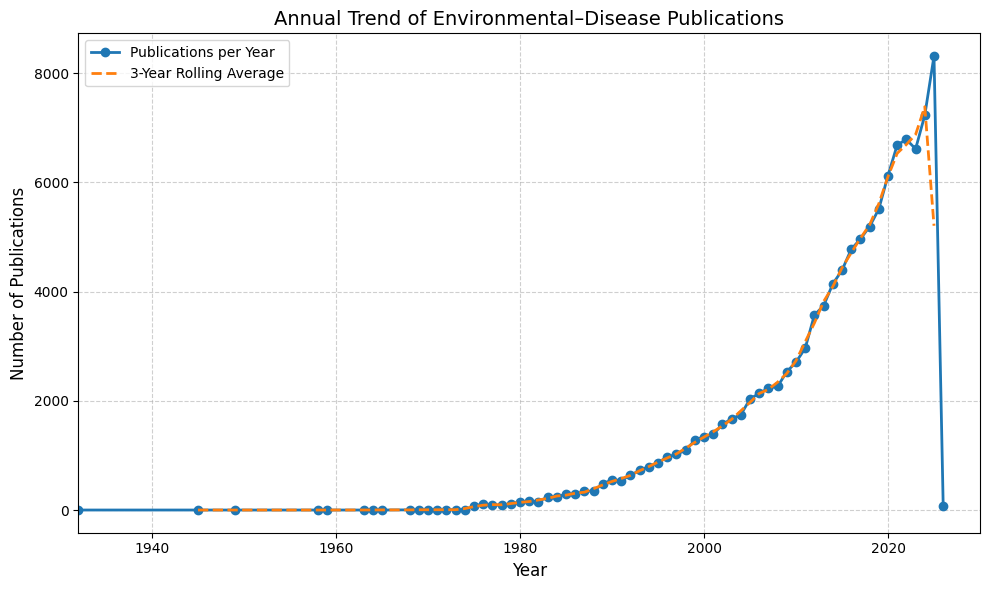

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df_clean = df.dropna(subset=['Year'])
pub_per_year = df_clean.groupby('Year').size().reset_index(name='Publications')
pub_per_year = pub_per_year.sort_values('Year')
pub_per_year['Rolling_Mean'] = pub_per_year['Publications'].rolling(window=3, center=True).mean()

plt.figure(figsize=(10, 6))

plt.plot(
    pub_per_year['Year'],
    pub_per_year['Publications'],
    marker='o',
    linewidth=2,
    label='Publications per Year'
)

plt.plot(
    pub_per_year['Year'],
    pub_per_year['Rolling_Mean'],
    linestyle='--',
    linewidth=2,
    label='3-Year Rolling Average'
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Publications", fontsize=12)
plt.title("Annual Trend of Environmental–Disease Publications", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.xlim(pub_per_year['Year'].min(), 2030)

plt.tight_layout()
plt.show()

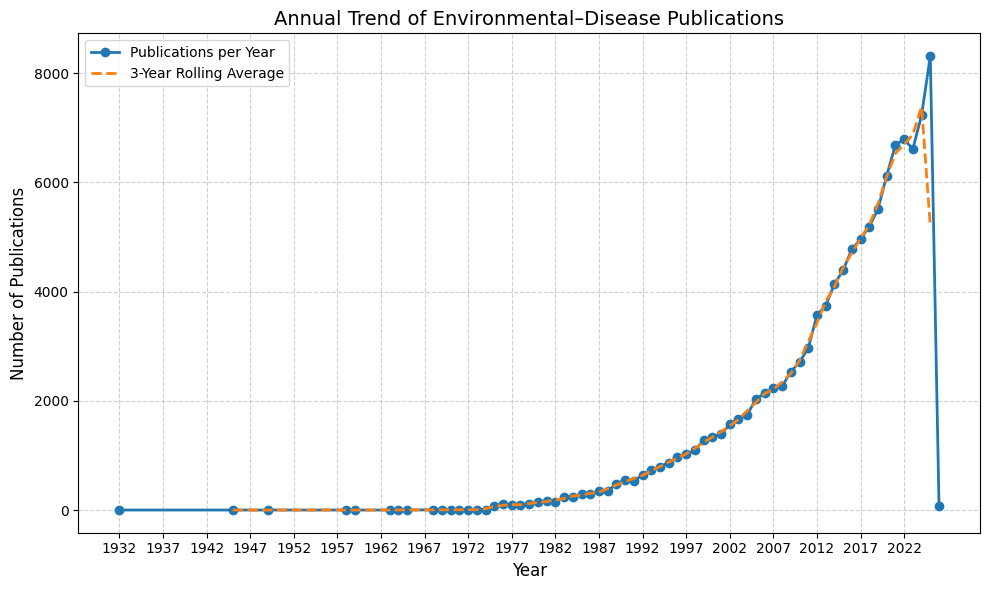

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df_clean = df.dropna(subset=['Year'])
pub_per_year = df_clean.groupby('Year').size().reset_index(name='Publications')

pub_per_year = pub_per_year[pub_per_year['Publications'] > 0]
pub_per_year = pub_per_year.sort_values('Year')
pub_per_year['Rolling_Mean'] = pub_per_year['Publications'].rolling(window=3, center=True).mean()

plt.figure(figsize=(10, 6))

plt.plot(
    pub_per_year['Year'],
    pub_per_year['Publications'],
    marker='o',
    linewidth=2,
    label='Publications per Year'
)

plt.plot(
    pub_per_year['Year'],
    pub_per_year['Rolling_Mean'],
    linestyle='--',
    linewidth=2,
    label='3-Year Rolling Average'
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Publications", fontsize=12)
plt.title("Annual Trend of Environmental–Disease Publications", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)

start_year = int(pub_per_year['Year'].min())
end_year = int(pub_per_year['Year'].max())

plt.xticks(np.arange(start_year, end_year + 1, 5))

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
pub_per_year['Growth_Rate_%'] = pub_per_year['Publications'].pct_change() * 100

print(pub_per_year.head())


   Year  Publications  Growth_Rate_%
0  1932             1            NaN
1  1945             1            0.0
2  1949             1            0.0
3  1958             1            0.0
4  1959             1            0.0


In [ ]:
before_2010 = pub_per_year[pub_per_year['Year'] < 2010]['Publications'].mean()
after_2010 = pub_per_year[pub_per_year['Year'] >= 2010]['Publications'].mean()

print("Average publications before 2010:", before_2010)
print("Average publications after 2010:", after_2010)

Average publications before 2010: 612.76
Average publications after 2010: 4928.64705882353


In [ ]:
surge_years = pub_per_year[pub_per_year['Growth_Rate_%'] > 20]

print("Surge Years:")
print(surge_years[['Year', 'Growth_Rate_%']])

Surge Years:
    Year  Growth_Rate_%
6   1964     300.000000
8   1968     300.000000
10  1970     125.000000
12  1972      25.000000
13  1973      80.000000
15  1975     871.428571
16  1976      72.058824
20  1980      39.449541
23  1983      50.955414
25  1985      20.164609
27  1987      20.979021
29  1989      37.142857
52  2012      20.553493


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

df_clean = df.dropna(subset=['Year'])
pub_per_year = df_clean.groupby('Year').size().reset_index(name='Publications')
pub_per_year = pub_per_year.sort_values('Year')
pub_per_year['Growth_Rate_%'] = pub_per_year['Publications'].pct_change() * 100
pub_per_year = pub_per_year.dropna(subset=['Growth_Rate_%'])

surge_years = pub_per_year[pub_per_year['Growth_Rate_%'] > 20]

print("Surge Years:")
print(surge_years[['Year', 'Growth_Rate_%']])

Surge Years:
    Year  Growth_Rate_%
6   1964     300.000000
8   1968     300.000000
10  1970     125.000000
12  1972      25.000000
13  1973      80.000000
15  1975     871.428571
16  1976      72.058824
20  1980      39.449541
23  1983      50.955414
25  1985      20.164609
27  1987      20.979021
29  1989      37.142857
52  2012      20.553493


Number of publications in 2025: 8314


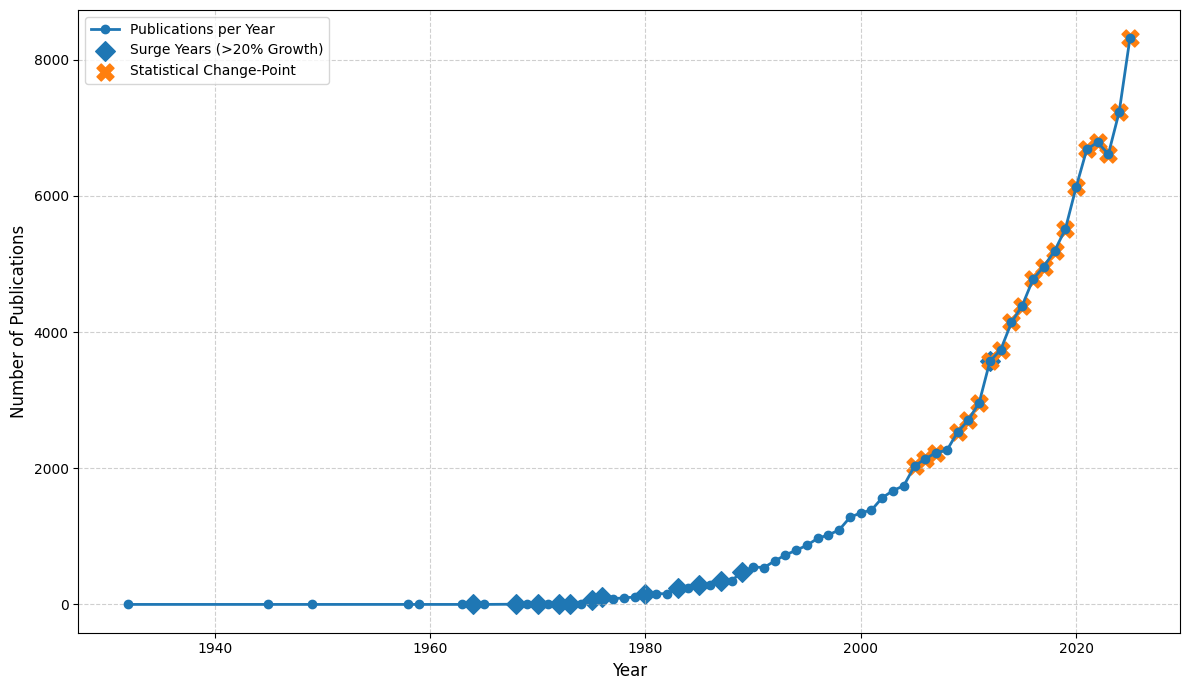

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df_clean = df.dropna(subset=['Year'])
pub_per_year = df_clean.groupby('Year').size().reset_index(name='Publications')
pub_per_year = pub_per_year.sort_values('Year')

pub_per_year = pub_per_year[pub_per_year['Year'] <= 2025]

pub_2025 = pub_per_year[pub_per_year['Year'] == 2025]

if pub_2025.empty:
    print("No publication data available for 2025.")
else:
    print("Number of publications in 2025:", int(pub_2025['Publications'].values[0]))

pub_per_year['Growth_Rate_%'] = pub_per_year['Publications'].pct_change() * 100

surge_years = pub_per_year[pub_per_year['Growth_Rate_%'] > 20]

window = 5
pub_per_year['Rolling_Mean'] = pub_per_year['Publications'].rolling(window=window).mean()
pub_per_year['Mean_Shift'] = pub_per_year['Rolling_Mean'].diff()

threshold = pub_per_year['Mean_Shift'].std()

change_points = pub_per_year[
    abs(pub_per_year['Mean_Shift']) > threshold
]

plt.figure(figsize=(12, 7))

plt.plot(
    pub_per_year['Year'],
    pub_per_year['Publications'],
    linewidth=2,
    marker='o',
    label='Publications per Year'
)

plt.scatter(
    surge_years['Year'],
    surge_years['Publications'],
    s=100,
    marker='D',
    label='Surge Years (>20% Growth)'
)

plt.scatter(
    change_points['Year'],
    change_points['Publications'],
    s=150,
    marker='X',
    label='Statistical Change-Point'
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Publications", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig("Trend Analysis.png", dpi=500, bbox_inches='tight')

plt.show()

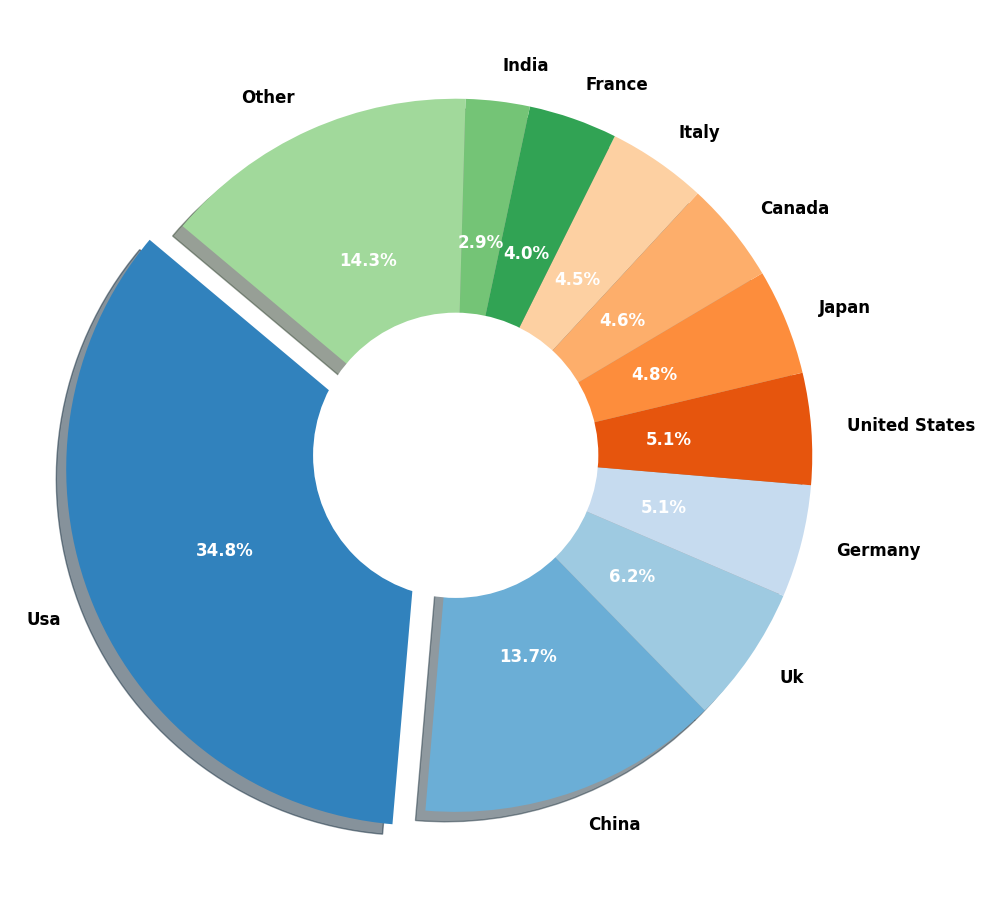

In [ ]:
import matplotlib.pyplot as plt


pub_per_country = df_clean['Country'].value_counts()
top_n = 10
top_countries = pub_per_country[:top_n]
other_count = pub_per_country[top_n:].sum()

labels = list(top_countries.index) + ['Other']
sizes = list(top_countries.values) + [other_count]
explode = [0.1 if i == 0 else 0 for i in range(len(labels))]
colors = plt.cm.tab20c.colors[:len(labels)]
plt.figure(figsize=(10, 10))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    shadow=True,
    colors=colors,
    textprops={'fontsize': 12, 'weight': 'bold', 'color':'black'}
)

for text in texts:
    text.set_color('black')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
centre_circle = plt.Circle((0, 0), 0.40, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.tight_layout()
plt.savefig("publications_by_country.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
pub_per_journal = df_clean['Journal'].value_counts()

top_journals = pub_per_journal[:10]
print("Top 10 Journals by Number of Publications:")
print(top_journals)

Top 10 Journals by Number of Publications:
Journal
International journal of radiation oncology, biology, physics        1893
PloS one                                                             1438
Environmental health perspectives                                    1223
Environmental research                                               1184
Scientific reports                                                    973
International journal of environmental research and public health     972
The Science of the total environment                                  892
Cureus                                                                776
Environment international                                             772
Cancer                                                                749
Name: count, dtype: int64


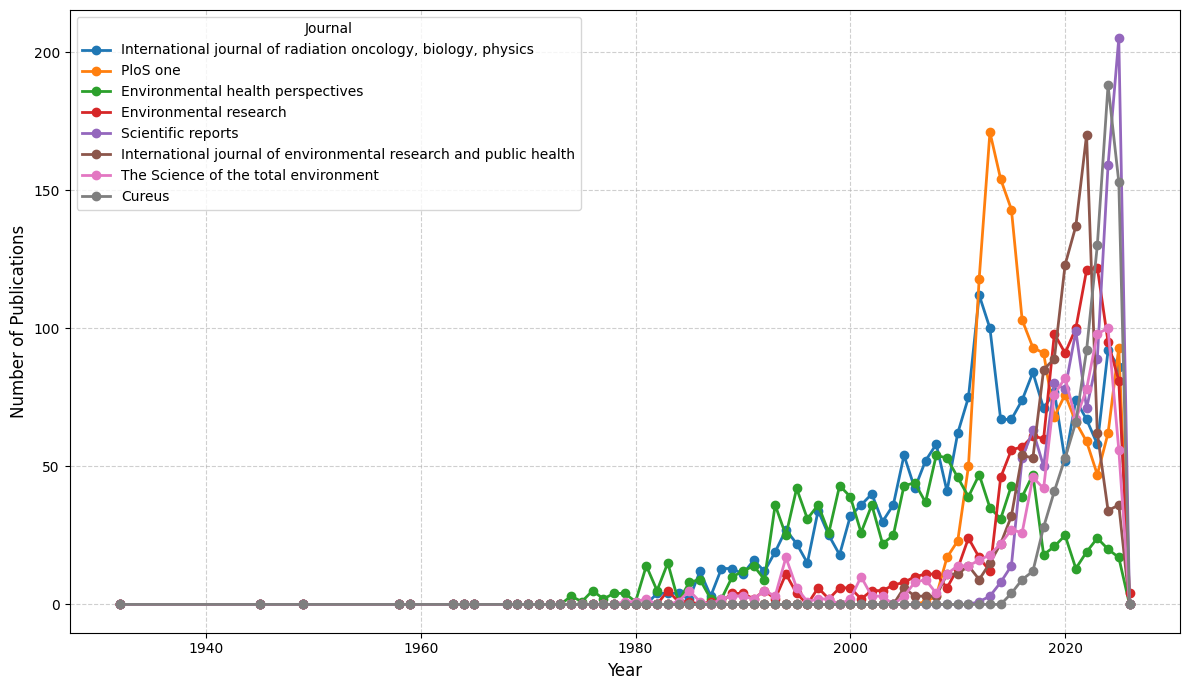

In [ ]:
journal_trend = df_clean.pivot_table(
    index='Year',
    columns='Journal',
    values='PMID',
    aggfunc='count'
).fillna(0)
top_journal_names = pub_per_journal[:8].index
journal_trend[top_journal_names].plot(
    figsize=(12, 7),
    marker='o',
    linewidth=2
)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Publications", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Journal')
plt.tight_layout()
plt.savefig("Publication_Trend.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

all_words = ' '.join(df['Abstract'].dropna()).lower().split()
all_words = [w for w in all_words if w.isalpha() and w not in stop_words]
word_freq = Counter(all_words)
print(word_freq.most_common(20))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('patients', 162104), ('cancer', 133762), ('risk', 121718), ('associated', 117681), ('exposure', 102532), ('study', 76263), ('radiation', 70538), ('lung', 59732), ('may', 56425), ('increased', 55490), ('disease', 54457), ('treatment', 53288), ('using', 48767), ('health', 43492), ('studies', 42994), ('among', 41981), ('higher', 41047), ('data', 40791), ('cell', 40598), ('significant', 40469)]


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,3), stop_words='english')
X = vectorizer.fit_transform(df['Abstract'].dropna())
sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
print(words_freq[:20])

[('95 ci', np.int64(55733)), ('sub sub', np.int64(36496)), ('lung cancer', np.int64(30868)), ('risk factors', np.int64(21115)), ('breast cancer', np.int64(20948)), ('radiation therapy', np.int64(18519)), ('air pollution', np.int64(17948)), ('sup sup', np.int64(17407)), ('pm sub', np.int64(16409)), ('long term', np.int64(14484)), ('pm sub sub', np.int64(13027)), ('increased risk', np.int64(12970)), ('cardiovascular disease', np.int64(12545)), ('95 confidence', np.int64(12474)), ('risk factor', np.int64(11624)), ('confidence interval', np.int64(10716)), ('cancer risk', np.int64(10520)), ('prostate cancer', np.int64(10215)), ('95 confidence interval', np.int64(10187)), ('associated increased', np.int64(9989))]


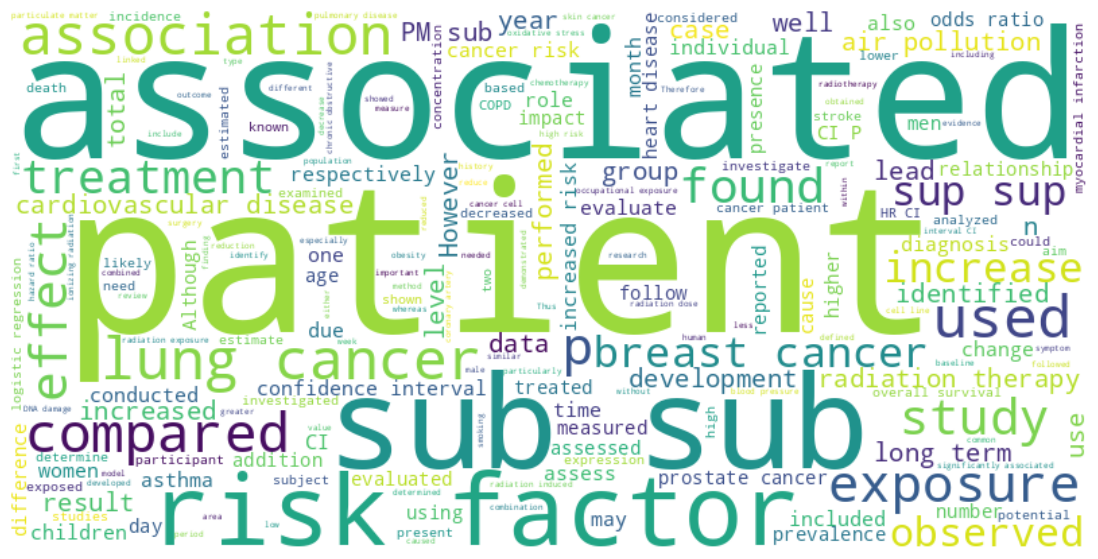

In [ ]:
from wordcloud import WordCloud

text = ' '.join(df['Abstract'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("wordcloud_abstarct.png", dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['Abstract'].dropna())

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

for i, topic in enumerate(lda.components_):
    print(f"Topic {i}:")
    print([vectorizer.get_feature_names_out()[index] for index in topic.argsort()[-10:]])

Topic 0:
['studies', 'risk', 'patient', 'review', 'lead', 'associated', 'treatment', 'clinical', 'patients', 'disease']
Topic 1:
['smoking', 'asthma', 'air', '95', 'study', 'health', 'cancer', 'risk', 'sub', 'exposure']
Topic 2:
['human', 'lung', 'radiation', 'dna', 'exposure', 'induced', 'expression', 'cancer', 'cell', 'cells']
Topic 3:
['risk', 'breast', 'dose', 'associated', 'therapy', 'survival', 'treatment', 'radiation', 'cancer', 'patients']
Topic 4:
['stroke', 'age', 'cardiovascular', 'ci', '95', 'study', 'disease', 'associated', 'risk', 'patients']
